In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix,ConfusionMatrixDisplay)


In [2]:
sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")


st=pd.DataFrame(sentiment)
td=pd.DataFrame(trades)


In [3]:
st

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05
...,...,...,...,...
2639,1745818200,54,Neutral,2025-04-28
2640,1745904600,60,Greed,2025-04-29
2641,1745991000,56,Greed,2025-04-30
2642,1746077400,53,Neutral,2025-05-01


In [4]:
print("Fear & Greed Shape:", sentiment.shape)
print("Trader Data Shape:", trades.shape)


Fear & Greed Shape: (2644, 4)
Trader Data Shape: (211224, 16)


In [5]:
st.columns = st.columns.str.lower().str.strip()

st['date'] = pd.to_datetime(st['date'])

st = st[['date', 'classification', 'value']]


st

,date,classification,value
0,2018-02-01,Fear,30
1,2018-02-02,Extreme Fear,15
2,2018-02-03,Fear,40
3,2018-02-04,Extreme Fear,24
4,2018-02-05,Extreme Fear,11
...,...,...,...
2639,2025-04-28,Neutral,54
2640,2025-04-29,Greed,60
2641,2025-04-30,Greed,56
2642,2025-05-01,Neutral,53


In [6]:
td.columns = td.columns.str.strip()

In [7]:
td

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,382.20,420.80,SELL,25-04-2025 15:35,7546.600000,Close Long,-20.2566,0xcd339c08dc7b615a993c0422374d8e02027400092bc2...,88803313862,False,0.042080,1.990000e+14,1.750000e+12
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,2124.10,2338.63,SELL,25-04-2025 15:35,7164.400000,Close Long,-112.5773,0x29e8ede2a3a37aa0eac00422374d8e02029b00ac9f3c...,88803313862,False,0.233863,9.260000e+14,1.750000e+12
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,423.40,466.16,SELL,25-04-2025 15:35,5040.300000,Close Long,-22.4402,0x0780085b0c0a943eea800422374d920204c100edf579...,88803313862,False,0.046616,6.930000e+14,1.750000e+12
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,3599.80,3963.38,SELL,25-04-2025 15:35,4616.900000,Close Long,-190.7894,0x349c29934913b25c89e20422374d920204cd008b8a0e...,88803313862,False,0.396337,4.180000e+14,1.750000e+12


In [8]:
td["Coin"].value_counts()

Coin
HYPE    68005
@107    29992
BTC     26064
ETH     11158
SOL     10691
        ...  
@48         1
@135        1
@21         1
@42         1
@32         1
Name: count, Length: 246, dtype: int64

In [9]:
td["Timestamp IST"]=pd.to_datetime(td["Timestamp IST"], dayfirst=True)
td


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,382.20,420.80,SELL,2025-04-25 15:35:00,7546.600000,Close Long,-20.2566,0xcd339c08dc7b615a993c0422374d8e02027400092bc2...,88803313862,False,0.042080,1.990000e+14,1.750000e+12
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,2124.10,2338.63,SELL,2025-04-25 15:35:00,7164.400000,Close Long,-112.5773,0x29e8ede2a3a37aa0eac00422374d8e02029b00ac9f3c...,88803313862,False,0.233863,9.260000e+14,1.750000e+12
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,423.40,466.16,SELL,2025-04-25 15:35:00,5040.300000,Close Long,-22.4402,0x0780085b0c0a943eea800422374d920204c100edf579...,88803313862,False,0.046616,6.930000e+14,1.750000e+12
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,3599.80,3963.38,SELL,2025-04-25 15:35:00,4616.900000,Close Long,-190.7894,0x349c29934913b25c89e20422374d920204cd008b8a0e...,88803313862,False,0.396337,4.180000e+14,1.750000e+12


In [10]:
td["date"]=td["Timestamp IST"].dt.normalize()
td['time'] = td['Timestamp IST'].dt.time
td

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,time
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,22:50:00
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,22:50:00
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,22:50:00
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,22:50:00
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,22:50:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,382.20,420.80,SELL,2025-04-25 15:35:00,7546.600000,Close Long,-20.2566,0xcd339c08dc7b615a993c0422374d8e02027400092bc2...,88803313862,False,0.042080,1.990000e+14,1.750000e+12,2025-04-25,15:35:00
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,2124.10,2338.63,SELL,2025-04-25 15:35:00,7164.400000,Close Long,-112.5773,0x29e8ede2a3a37aa0eac00422374d8e02029b00ac9f3c...,88803313862,False,0.233863,9.260000e+14,1.750000e+12,2025-04-25,15:35:00
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,423.40,466.16,SELL,2025-04-25 15:35:00,5040.300000,Close Long,-22.4402,0x0780085b0c0a943eea800422374d920204c100edf579...,88803313862,False,0.046616,6.930000e+14,1.750000e+12,2025-04-25,15:35:00
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,3599.80,3963.38,SELL,2025-04-25 15:35:00,4616.900000,Close Long,-190.7894,0x349c29934913b25c89e20422374d920204cd008b8a0e...,88803313862,False,0.396337,4.180000e+14,1.750000e+12,2025-04-25,15:35:00


In [12]:
df1=td.drop(["Timestamp IST",], axis=1)


In [13]:
df = pd.merge(
    st,
    df1,
    on=["date"],
    how='right'
)

df


,date,classification,value,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,time
0,2024-12-02,Extreme Greed,80.0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,0.000000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,22:50:00
1,2024-12-02,Extreme Greed,80.0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,986.524596,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,22:50:00
2,2024-12-02,Extreme Greed,80.0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,1002.518996,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,22:50:00
3,2024-12-02,Extreme Greed,80.0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,1146.558564,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,22:50:00
4,2024-12-02,Extreme Greed,80.0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,1289.488521,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,22:50:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,2025-04-25,Greed,60.0,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,382.20,420.80,SELL,7546.600000,Close Long,-20.2566,0xcd339c08dc7b615a993c0422374d8e02027400092bc2...,88803313862,False,0.042080,1.990000e+14,1.750000e+12,15:35:00
211220,2025-04-25,Greed,60.0,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,2124.10,2338.63,SELL,7164.400000,Close Long,-112.5773,0x29e8ede2a3a37aa0eac00422374d8e02029b00ac9f3c...,88803313862,False,0.233863,9.260000e+14,1.750000e+12,15:35:00
211221,2025-04-25,Greed,60.0,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,423.40,466.16,SELL,5040.300000,Close Long,-22.4402,0x0780085b0c0a943eea800422374d920204c100edf579...,88803313862,False,0.046616,6.930000e+14,1.750000e+12,15:35:00
211222,2025-04-25,Greed,60.0,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,3599.80,3963.38,SELL,4616.900000,Close Long,-190.7894,0x349c29934913b25c89e20422374d920204cd008b8a0e...,88803313862,False,0.396337,4.180000e+14,1.750000e+12,15:35:00


In [14]:
df=df.dropna()

In [15]:
df.isnull().sum()

date                0
classification      0
value               0
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
time                0
dtype: int64

In [16]:
df['Win'] = (df['Closed PnL'] > 0).astype(int)

df

C:\Users\New\AppData\Local\Temp\ipykernel_7036\1764609245.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Win'] = (df['Closed PnL'] > 0).astype(int)


,date,classification,value,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,time,Win
0,2024-12-02,Extreme Greed,80.0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,0.000000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,22:50:00,0
1,2024-12-02,Extreme Greed,80.0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,986.524596,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,22:50:00,0
2,2024-12-02,Extreme Greed,80.0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,1002.518996,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,22:50:00,0
3,2024-12-02,Extreme Greed,80.0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,1146.558564,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,22:50:00,0
4,2024-12-02,Extreme Greed,80.0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,1289.488521,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,22:50:00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,2025-04-25,Greed,60.0,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,382.20,420.80,SELL,7546.600000,Close Long,-20.2566,0xcd339c08dc7b615a993c0422374d8e02027400092bc2...,88803313862,False,0.042080,1.990000e+14,1.750000e+12,15:35:00,0
211220,2025-04-25,Greed,60.0,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,2124.10,2338.63,SELL,7164.400000,Close Long,-112.5773,0x29e8ede2a3a37aa0eac00422374d8e02029b00ac9f3c...,88803313862,False,0.233863,9.260000e+14,1.750000e+12,15:35:00,0
211221,2025-04-25,Greed,60.0,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,423.40,466.16,SELL,5040.300000,Close Long,-22.4402,0x0780085b0c0a943eea800422374d920204c100edf579...,88803313862,False,0.046616,6.930000e+14,1.750000e+12,15:35:00,0
211222,2025-04-25,Greed,60.0,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,3599.80,3963.38,SELL,4616.900000,Close Long,-190.7894,0x349c29934913b25c89e20422374d920204cd008b8a0e...,88803313862,False,0.396337,4.180000e+14,1.750000e+12,15:35:00,0


In [17]:
summary = df.groupby('classification').agg(

    Trades=('Closed PnL','count'),
    Total_PnL=('Closed PnL','sum'),
    Average_PnL=('Closed PnL','mean'),
    Median_PnL=('Closed PnL','median'),
    Win_Rate=('Win','mean'),
    Avg_Trade_Size=('Size USD','mean'),
    Avg_Fee=('Fee','mean')

)
summary['Win_Rate'] *= 100

print(summary)


                Trades     Total_PnL  Average_PnL  Median_PnL   Win_Rate  \
classification                                                             
Extreme Fear     21400  7.391102e+05    34.537862         0.0  37.060748   
Extreme Greed    39992  2.715171e+06    67.892861         0.0  46.494299   
Fear             61837  3.357155e+06    54.290400         0.0  42.076750   
Greed            50303  2.150129e+06    42.743559         0.0  38.482794   
Neutral          37686  1.292921e+06    34.307718         0.0  39.699093   

                Avg_Trade_Size   Avg_Fee  
classification                            
Extreme Fear       5349.731843  1.116291  
Extreme Greed      3112.251565  0.675902  
Fear               7816.109931  1.495172  
Greed              5736.884375  1.254372  
Neutral            4782.732661  1.044798  


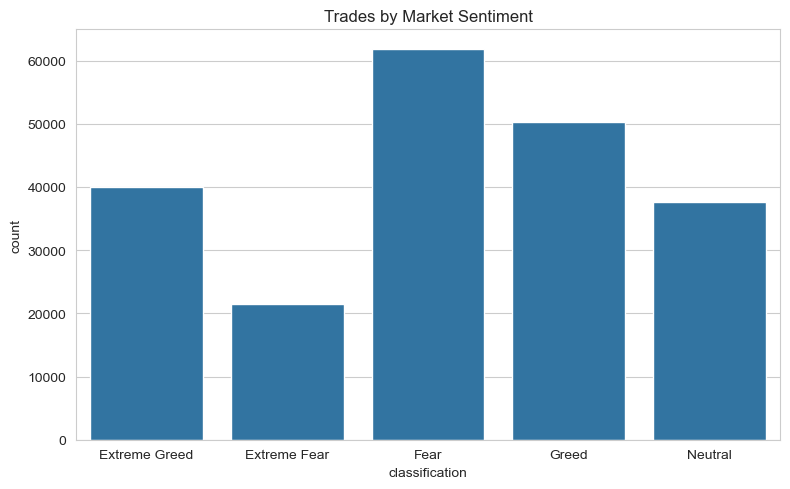

In [28]:
# 1 Sentiment Distribution

sns.set_style("whitegrid")

plt.figure(figsize=(8,5))
sns.countplot(data=df,x='classification')
plt.title("Trades by Market Sentiment")
plt.xticks()
plt.tight_layout()
plt.show()

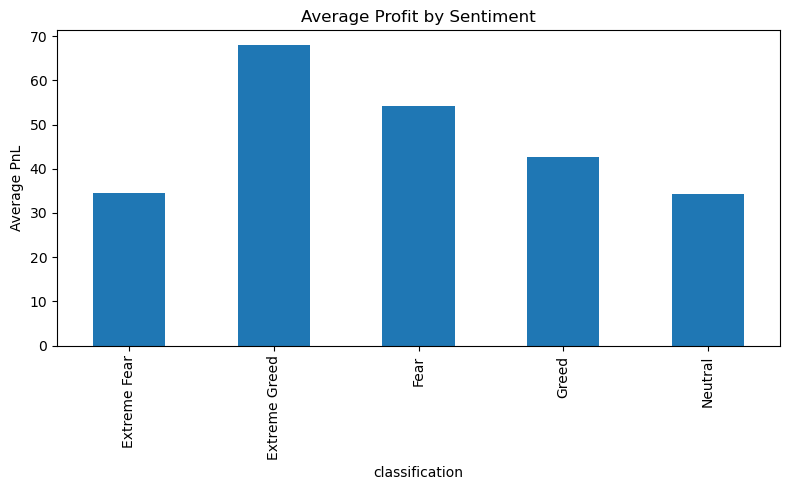

In [18]:
#Avrage profit

plt.figure(figsize=(8,5))

df.groupby('classification')['Closed PnL'].mean().plot(
    kind='bar'
)

plt.ylabel("Average PnL")
plt.title("Average Profit by Sentiment")
plt.tight_layout()

plt.show()

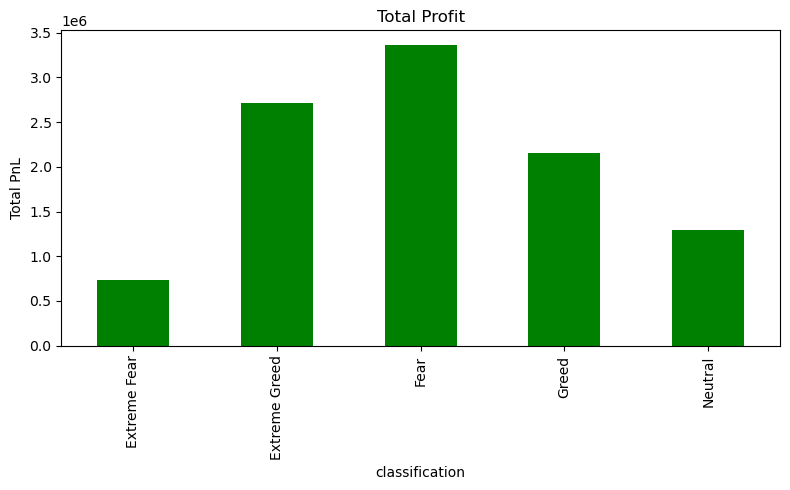

In [19]:
# 3 Total Profit

plt.figure(figsize=(8,5))

df.groupby('classification')['Closed PnL'].sum().plot(
    kind='bar',
    color='green'
)

plt.ylabel("Total PnL")
plt.title("Total Profit")
plt.tight_layout()
plt.show()

In [20]:
df

,date,classification,value,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,time,Win
0,2024-12-02,Extreme Greed,80.0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,0.000000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,22:50:00,0
1,2024-12-02,Extreme Greed,80.0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,986.524596,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,22:50:00,0
2,2024-12-02,Extreme Greed,80.0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,1002.518996,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,22:50:00,0
3,2024-12-02,Extreme Greed,80.0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,1146.558564,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,22:50:00,0
4,2024-12-02,Extreme Greed,80.0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,1289.488521,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,22:50:00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,2025-04-25,Greed,60.0,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,382.20,420.80,SELL,7546.600000,Close Long,-20.2566,0xcd339c08dc7b615a993c0422374d8e02027400092bc2...,88803313862,False,0.042080,1.990000e+14,1.750000e+12,15:35:00,0
211220,2025-04-25,Greed,60.0,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,2124.10,2338.63,SELL,7164.400000,Close Long,-112.5773,0x29e8ede2a3a37aa0eac00422374d8e02029b00ac9f3c...,88803313862,False,0.233863,9.260000e+14,1.750000e+12,15:35:00,0
211221,2025-04-25,Greed,60.0,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,423.40,466.16,SELL,5040.300000,Close Long,-22.4402,0x0780085b0c0a943eea800422374d920204c100edf579...,88803313862,False,0.046616,6.930000e+14,1.750000e+12,15:35:00,0
211222,2025-04-25,Greed,60.0,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,3599.80,3963.38,SELL,4616.900000,Close Long,-190.7894,0x349c29934913b25c89e20422374d920204cd008b8a0e...,88803313862,False,0.396337,4.180000e+14,1.750000e+12,15:35:00,0


In [21]:
# Trader Profit Prediction using Market Sentiment

df1=df.drop(["Account","Transaction Hash","Order ID","Trade ID"], axis=1)
df1

,date,classification,value,Coin,Execution Price,Size Tokens,Size USD,Side,Start Position,Direction,Closed PnL,Crossed,Fee,Timestamp,time,Win
0,2024-12-02,Extreme Greed,80.0,@107,7.9769,986.87,7872.16,BUY,0.000000,Buy,0.0000,True,0.345404,1.730000e+12,22:50:00,0
1,2024-12-02,Extreme Greed,80.0,@107,7.9800,16.00,127.68,BUY,986.524596,Buy,0.0000,True,0.005600,1.730000e+12,22:50:00,0
2,2024-12-02,Extreme Greed,80.0,@107,7.9855,144.09,1150.63,BUY,1002.518996,Buy,0.0000,True,0.050431,1.730000e+12,22:50:00,0
3,2024-12-02,Extreme Greed,80.0,@107,7.9874,142.98,1142.04,BUY,1146.558564,Buy,0.0000,True,0.050043,1.730000e+12,22:50:00,0
4,2024-12-02,Extreme Greed,80.0,@107,7.9894,8.73,69.75,BUY,1289.488521,Buy,0.0000,True,0.003055,1.730000e+12,22:50:00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,2025-04-25,Greed,60.0,FARTCOIN,1.1010,382.20,420.80,SELL,7546.600000,Close Long,-20.2566,False,0.042080,1.750000e+12,15:35:00,0
211220,2025-04-25,Greed,60.0,FARTCOIN,1.1010,2124.10,2338.63,SELL,7164.400000,Close Long,-112.5773,False,0.233863,1.750000e+12,15:35:00,0
211221,2025-04-25,Greed,60.0,FARTCOIN,1.1010,423.40,466.16,SELL,5040.300000,Close Long,-22.4402,False,0.046616,1.750000e+12,15:35:00,0
211222,2025-04-25,Greed,60.0,FARTCOIN,1.1010,3599.80,3963.38,SELL,4616.900000,Close Long,-190.7894,False,0.396337,1.750000e+12,15:35:00,0


In [22]:
df1["day"]=df1["date"].dt.day
df1["month"]=df1["date"].dt.month
df1["year"]=df1["date"].dt.year

#time_cols = df1.select_dtypes(include=['datetime64']).columns.tolist()
#for col in time_cols:
    # Extract time-based features from datetime columns
    #df1['hour'] = df1[col].dt.hour
    #df1['minute'] = df1[col].dt.minute
    #df1['second'] = df1[col].dt.second

df1

,date,classification,value,Coin,Execution Price,Size Tokens,Size USD,Side,Start Position,Direction,Closed PnL,Crossed,Fee,Timestamp,time,Win,day,month,year
0,2024-12-02,Extreme Greed,80.0,@107,7.9769,986.87,7872.16,BUY,0.000000,Buy,0.0000,True,0.345404,1.730000e+12,22:50:00,0,2,12,2024
1,2024-12-02,Extreme Greed,80.0,@107,7.9800,16.00,127.68,BUY,986.524596,Buy,0.0000,True,0.005600,1.730000e+12,22:50:00,0,2,12,2024
2,2024-12-02,Extreme Greed,80.0,@107,7.9855,144.09,1150.63,BUY,1002.518996,Buy,0.0000,True,0.050431,1.730000e+12,22:50:00,0,2,12,2024
3,2024-12-02,Extreme Greed,80.0,@107,7.9874,142.98,1142.04,BUY,1146.558564,Buy,0.0000,True,0.050043,1.730000e+12,22:50:00,0,2,12,2024
4,2024-12-02,Extreme Greed,80.0,@107,7.9894,8.73,69.75,BUY,1289.488521,Buy,0.0000,True,0.003055,1.730000e+12,22:50:00,0,2,12,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,2025-04-25,Greed,60.0,FARTCOIN,1.1010,382.20,420.80,SELL,7546.600000,Close Long,-20.2566,False,0.042080,1.750000e+12,15:35:00,0,25,4,2025
211220,2025-04-25,Greed,60.0,FARTCOIN,1.1010,2124.10,2338.63,SELL,7164.400000,Close Long,-112.5773,False,0.233863,1.750000e+12,15:35:00,0,25,4,2025
211221,2025-04-25,Greed,60.0,FARTCOIN,1.1010,423.40,466.16,SELL,5040.300000,Close Long,-22.4402,False,0.046616,1.750000e+12,15:35:00,0,25,4,2025
211222,2025-04-25,Greed,60.0,FARTCOIN,1.1010,3599.80,3963.38,SELL,4616.900000,Close Long,-190.7894,False,0.396337,1.750000e+12,15:35:00,0,25,4,2025


In [29]:
X= df1.drop("date", axis=1)
X

,classification,value,Coin,Execution Price,Size Tokens,Size USD,Side,Start Position,Direction,Closed PnL,Crossed,Fee,Timestamp,time,Win,day,month,year
0,Extreme Greed,80.0,@107,7.9769,986.87,7872.16,BUY,0.000000,Buy,0.0000,True,0.345404,1.730000e+12,22:50:00,0,2,12,2024
1,Extreme Greed,80.0,@107,7.9800,16.00,127.68,BUY,986.524596,Buy,0.0000,True,0.005600,1.730000e+12,22:50:00,0,2,12,2024
2,Extreme Greed,80.0,@107,7.9855,144.09,1150.63,BUY,1002.518996,Buy,0.0000,True,0.050431,1.730000e+12,22:50:00,0,2,12,2024
3,Extreme Greed,80.0,@107,7.9874,142.98,1142.04,BUY,1146.558564,Buy,0.0000,True,0.050043,1.730000e+12,22:50:00,0,2,12,2024
4,Extreme Greed,80.0,@107,7.9894,8.73,69.75,BUY,1289.488521,Buy,0.0000,True,0.003055,1.730000e+12,22:50:00,0,2,12,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,Greed,60.0,FARTCOIN,1.1010,382.20,420.80,SELL,7546.600000,Close Long,-20.2566,False,0.042080,1.750000e+12,15:35:00,0,25,4,2025
211220,Greed,60.0,FARTCOIN,1.1010,2124.10,2338.63,SELL,7164.400000,Close Long,-112.5773,False,0.233863,1.750000e+12,15:35:00,0,25,4,2025
211221,Greed,60.0,FARTCOIN,1.1010,423.40,466.16,SELL,5040.300000,Close Long,-22.4402,False,0.046616,1.750000e+12,15:35:00,0,25,4,2025
211222,Greed,60.0,FARTCOIN,1.1010,3599.80,3963.38,SELL,4616.900000,Close Long,-190.7894,False,0.396337,1.750000e+12,15:35:00,0,25,4,2025


In [30]:
print(X.dtypes)

classification      object
value              float64
Coin                object
Execution Price    float64
Size Tokens        float64
Size USD           float64
Side                object
Start Position     float64
Direction           object
Closed PnL         float64
Crossed               bool
Fee                float64
Timestamp          float64
time                object
Win                  int32
day                  int32
month                int32
year                 int32
dtype: object


In [35]:
x = X.drop("Win", axis=1)
y = X["Win"]

categorical_cols = ['classification','Coin','Side','Direction',"time","Direction"]

le = LabelEncoder()

for col in categorical_cols:
    # Improved conversion to handle datetime.time objects properly
    x[col] = le.fit_transform(x[col].astype(str))
    #x[col] = x[col].apply(lambda val: val.strftime('%H:%M:%S') if hasattr(val, 'strftime') 
                         #else str(val) if val is not None else 'None')
    #x[col] = le.fit_transform(x[col])

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42, stratify=y)

model = RandomForestClassifier(n_estimators=200, random_state=42)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print("Accuracy :", accuracy_score(y_test, y_pred))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

Accuracy : 1.0

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     24871
           1       1.00      1.00      1.00     17373

    accuracy                           1.00     42244
   macro avg       1.00      1.00      1.00     42244
weighted avg       1.00      1.00      1.00     42244

